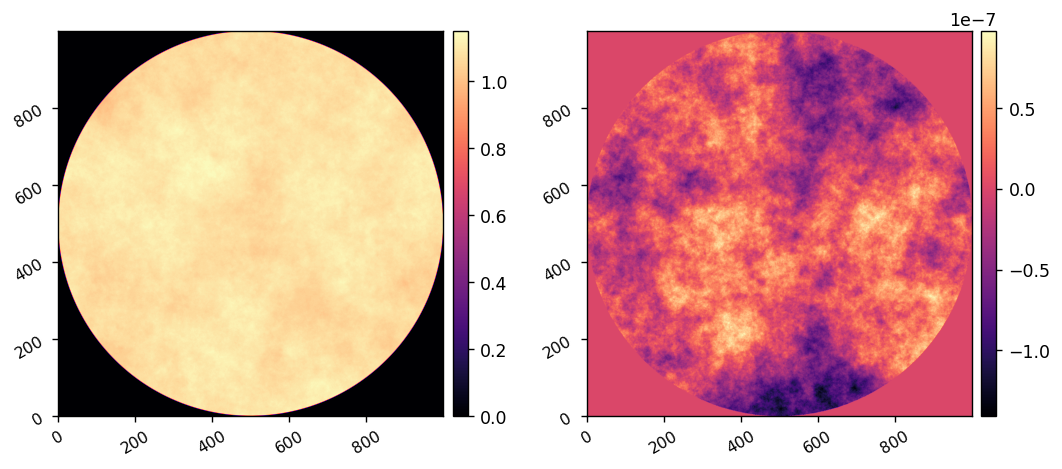

In [1]:
import numpy as np
import astropy.units as u
from astropy.io import fits
import copy
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
from importlib import reload

from scipy.optimize import minimize

from aefc_vortex.math_module import xp, xcipy, ensure_np_array
from aefc_vortex import utils
from aefc_vortex.imshows import imshow1, imshow2, imshow3, plot_data
from aefc_vortex import dm
from aefc_vortex import props
from aefc_vortex import aefc_1dm as adefc
import aefc_vortex.scoob_model as scoobm

wavelength_c = 633e-9

wfe_amp = utils.load_fits('data/example_wfe_amp.fits')
wfe_opd = utils.load_fits('data/example_wfe_opd.fits')
imshow2(wfe_amp, wfe_opd)

# wfe_amp = utils.load_fits('data/pr_est_amp.fits')
# wfe_opd = utils.load_fits('data/pr_est_opd.fits')
# imshow2(wfe_amp, wfe_opd)



# Test the forward model parameters.

Oversampling > 2x suggested for reliable results in Fresnel propagation.


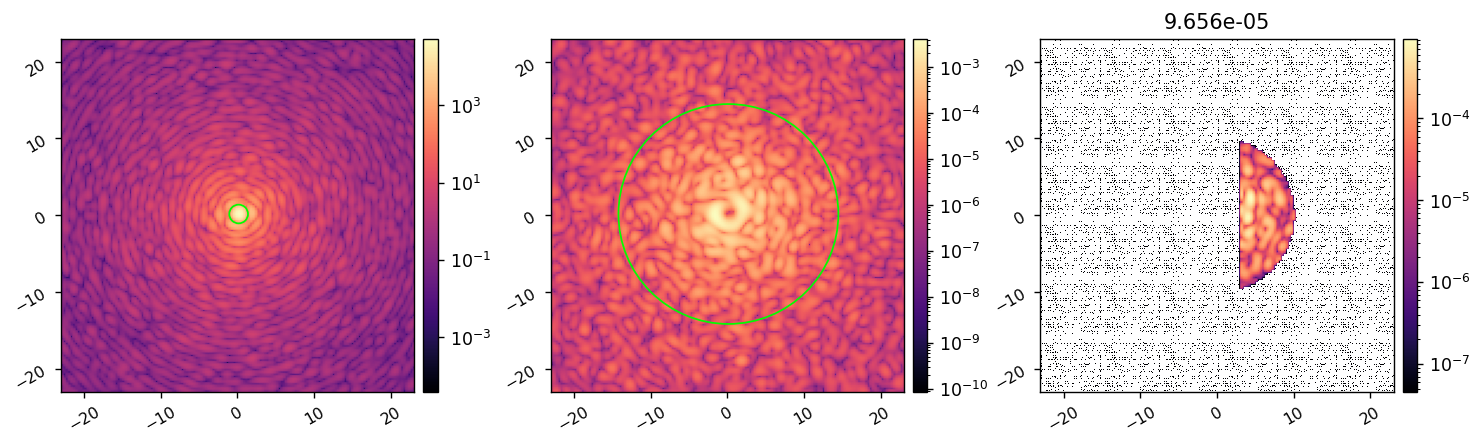

In [2]:
reload(scoobm)
I = scoobm.MODEL(
    # dm_beam_diam=9.4*u.mm, 
    # lyot_pupil_diam=9.4*u.mm,
    # dm_shift=np.array([0,0])*u.mm,
    # lyot_shift=np.array([0,0.3])*u.mm,
)
I.AMP = wfe_amp
I.OPD = wfe_opd

# I.flip_dm = 1
# I.flip_lyot_ud = 1
# I.det_rotation = -7.5

I.reverse_lyot = 1
I.flip_lyot = 1
# I.det_rotation = 178

I.setattr('use_vortex', False)
ref_psf = I.snap()
I.setattr('Imax_ref', xp.max(ref_psf))
I.setattr('use_vortex', True)
ref_coro_im = I.snap()

iwa = 3
owa = 10
rot = 0
control_mask = utils.create_annular_focal_plane_mask(I.npsf, I.psf_pixelscale_lamDc, irad=iwa, orad=owa, edge=iwa, rotation=rot)
mean_ni = xp.mean(ref_coro_im[control_mask])

psf_center = (I.psf_pixelscale_lamDc/2, I.psf_pixelscale_lamDc/2)
imshow3(
    ref_psf, ref_coro_im, ref_coro_im*control_mask, 
    '', '', f'{mean_ni:.3e}',
    lognorm=True, pxscl=I.psf_pixelscale_lamDc, 
    patches1=[Circle(psf_center, 1.22, fill=False, color='lime')], 
    patches2=[Circle(psf_center, I.control_rad, fill=False, color='lime')],
)

Oversampling > 2x suggested for reliable results in Fresnel propagation.


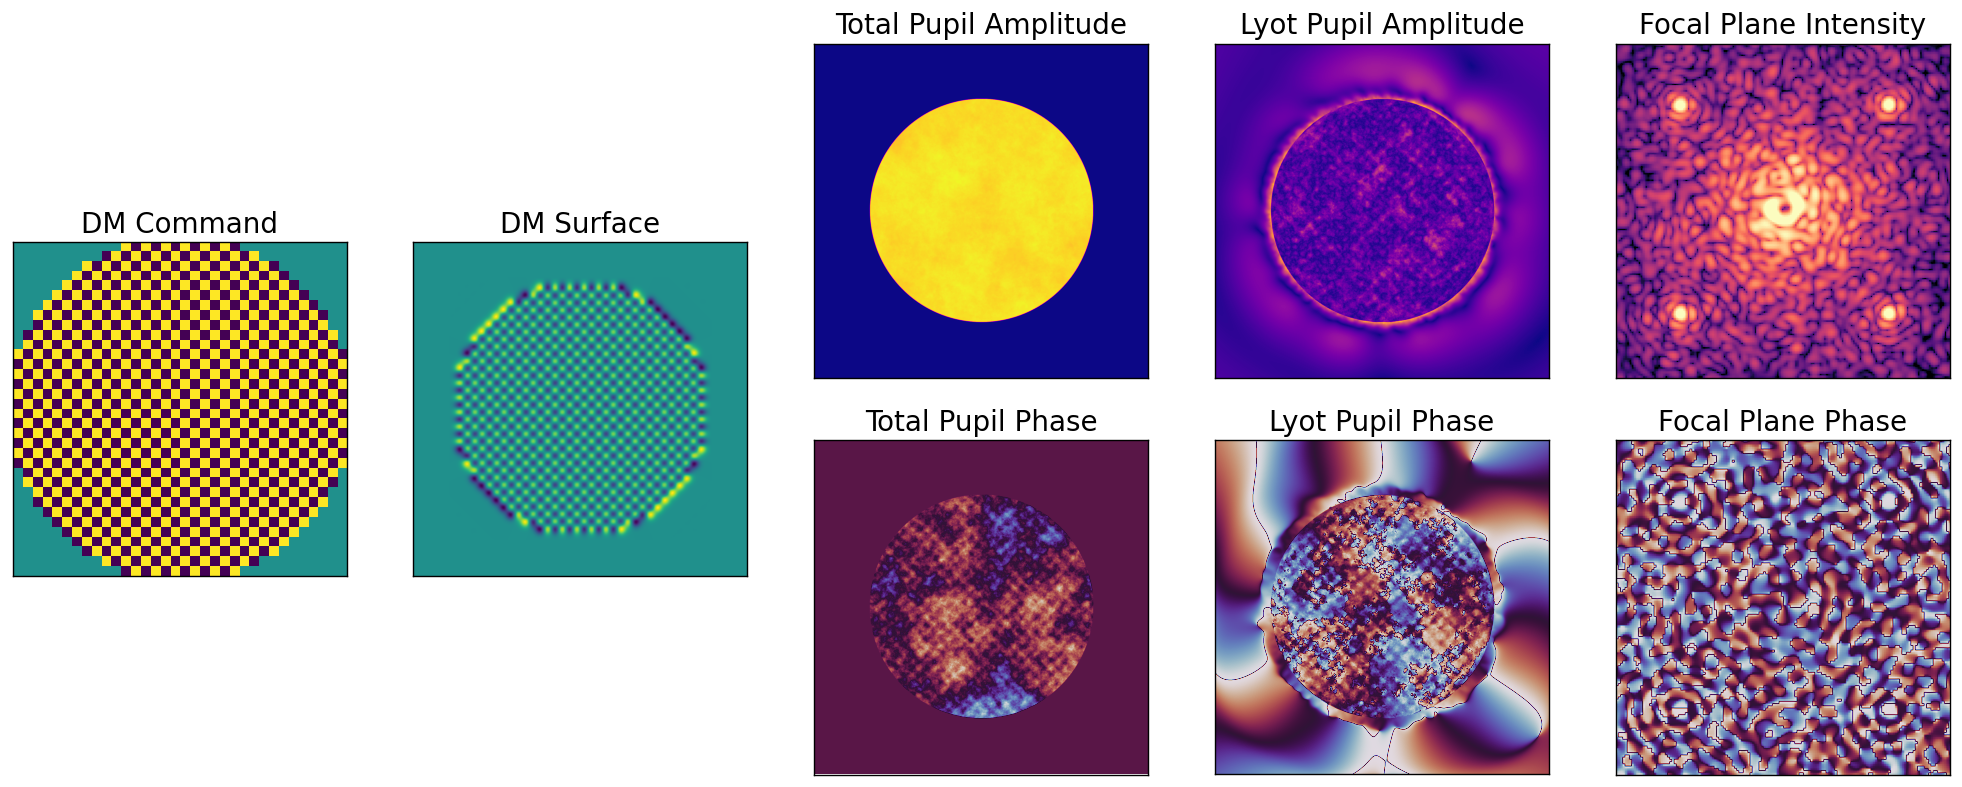

In [3]:
reload(scoobm)
reload(utils)
M = scoobm.MODEL(
    # dm_beam_diam=9.4*u.mm, 
    # lyot_pupil_diam=9.4*u.mm,
    # dm_shift=np.array([0,0])*u.mm,
    # lyot_shift=np.array([0,0.3])*u.mm,
)
M.AMP = wfe_amp
M.OPD = wfe_opd

# M.flip_dm = 1
# M.flip_lyot_ud = 1
# M.det_rotation = -7.5

M.reverse_lyot = 1
M.flip_lyot = 1
# M.det_rotation = 178

M.setattr('use_vortex', False)
ref_psf = M.snap()
M.setattr('Imax_ref', xp.max(ref_psf))

command = np.zeros((M.Nact, M.Nact))
command = 30e-9*utils.make_f(h=10, w=6, shift=(0,0))
command = 20e-9*utils.make_fourier_command(x_cpa=17, y_cpa=17)
# fpwf = M.forward(acts, use_vortex=0, plot=True)
fpwf = M.forward(
    command[M.dm_mask], use_vortex=1, 
    plot=0, fancy_plot=1, 
    fancy_plot_fname='../figs/forward_model.pdf',
)


	Cost-function J_delE: 0.099
	Cost-function J_c: 0.000
	Cost-function normalization factor: 0.099
	Total cost-function value: 1.000



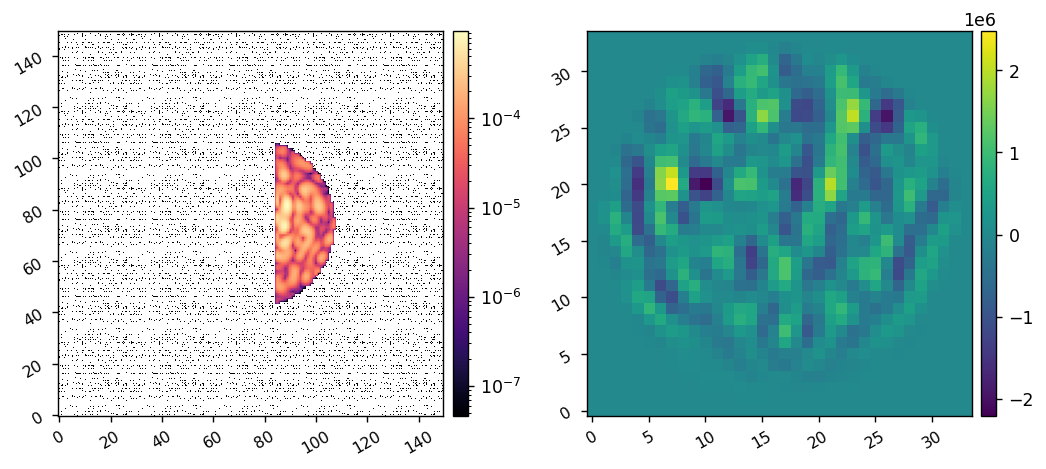

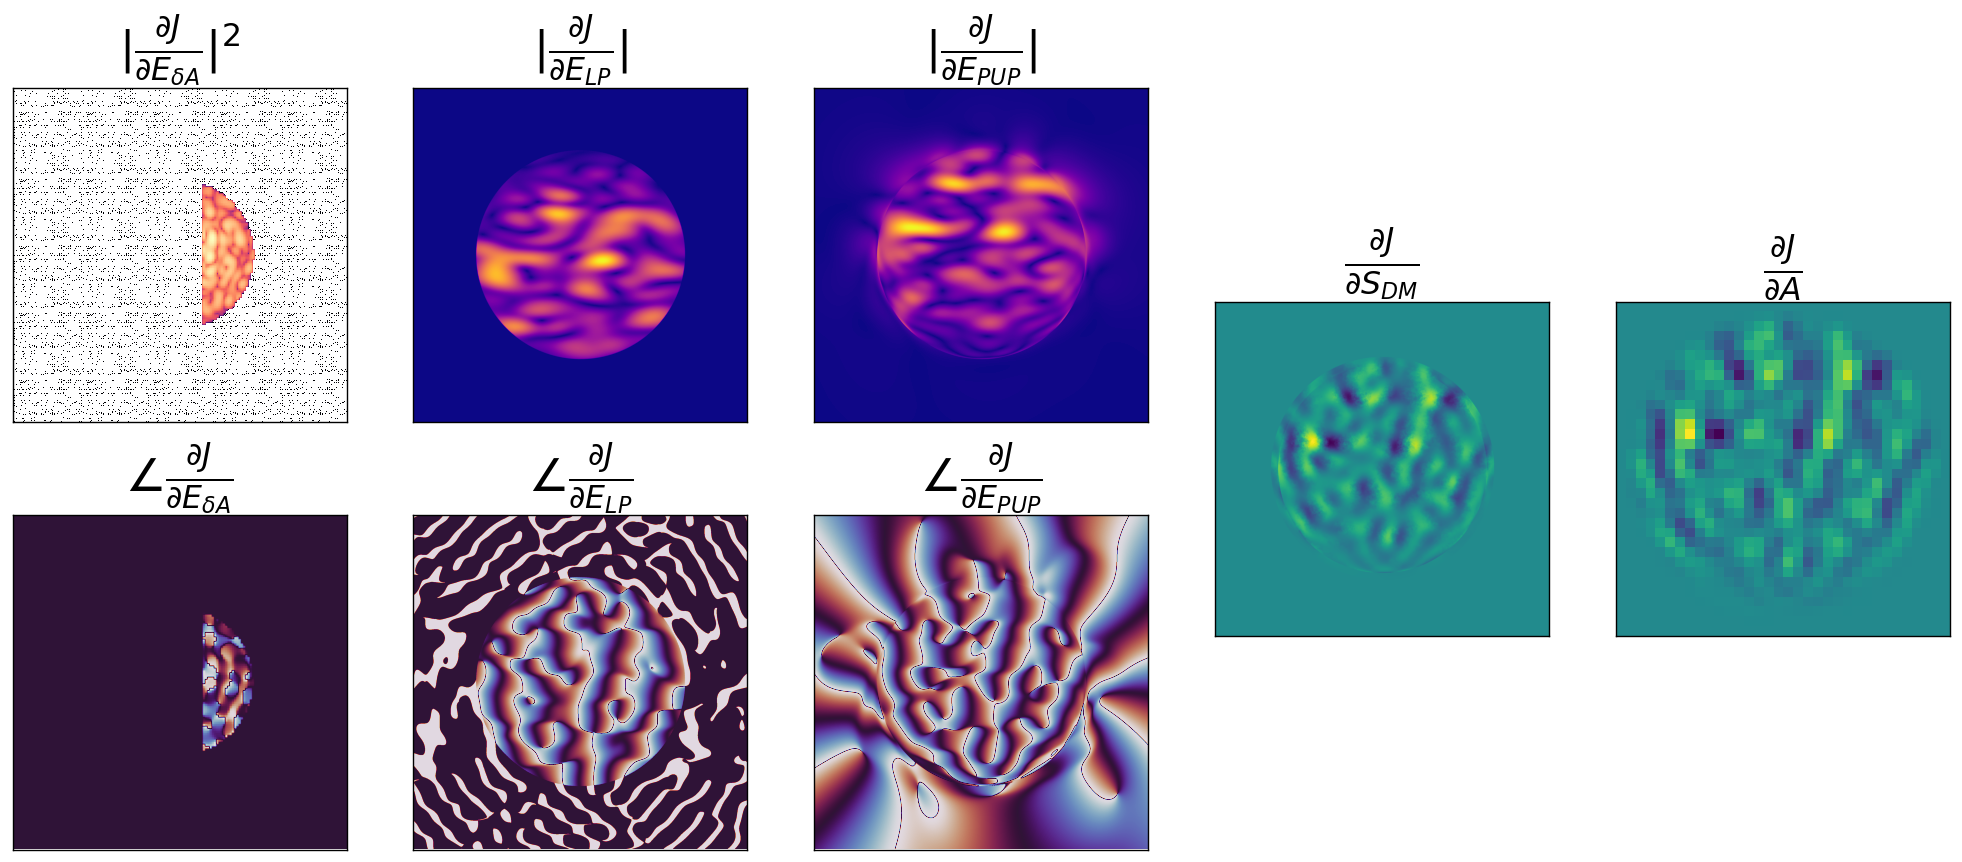

In [ ]:
reload(scoobm)

current_acts = xp.zeros(I.Nacts)
# current_acts = xp.array(fits.getdata('ad_test_acts.fits'))

I.set_dm(scoobm.acts_to_command(current_acts, I.dm_mask))
E_ab = I.calc_wf() * control_mask
E_FP_NOM = M.forward(current_acts, wavelength=I.wavelength_c, use_vortex=True, return_ints=0)

rmad_params = {
    'E_ab': E_ab,
    'current_acts': current_acts,
    'E_FP_NOM': E_FP_NOM, 
    'control_mask': control_mask,
    'wavelength':I.wavelength_c,
    'r_cond': 1e-3, 
}

del_acts = xp.zeros(M.Nacts)
J, dJ_dA = scoobm.val_and_grad(
    del_acts, M, rmad_params, verbose=True, 
    plot=0, fancy_plot=1, 
    # fancy_plot_fname='../figs/adjoint_model.pdf',
)

dm_grad = scoobm.acts_to_command(dJ_dA, M.dm_mask)
imshow2(xp.abs(E_ab)**2, dm_grad, lognorm1=True, cmap2='viridis')

In [ ]:
reload(scoobm)
current_acts = xp.zeros(I.Nacts)
# current_acts = xp.array( fits.getdata('ad_test_acts.fits') )

I.set_dm(scoobm.acts_to_command(current_acts, I.dm_mask))
E_ab = I.calc_wf() * control_mask
E_FP_NOM = M.forward(current_acts, wavelength=I.wavelength_c, use_vortex=True, return_ints=0)

rmad_params = {
    'E_ab': E_ab,
    'current_acts': current_acts,
    'E_FP_NOM': E_FP_NOM, 
    'control_mask': control_mask,
    'wavelength':I.wavelength_c,
    'r_cond': 1e-3, 
}

bfgs_tol = 1e-3
bfgs_opts = {
    'disp':True,
    # 'ftol':1e-6,
    # 'gtol':1e-6,
}

del_acts0 = np.zeros(M.Nacts)
res = minimize(
    scoobm.val_and_grad, 
    jac=True, 
    x0=del_acts0,
    args=(M, rmad_params, 0, 0, 0), 
    method='L-BFGS-B',
    tol=bfgs_tol,
    options=bfgs_opts,
)


 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =          952     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.00000D+00    |proj g|=  2.47428D+06

At iterate    1    f=  1.47393D-01    |proj g|=  6.56006D+05

At iterate    2    f=  5.32856D-02    |proj g|=  2.79100D+05

At iterate    3    f=  2.32487D-02    |proj g|=  1.27605D+05

At iterate    4    f=  1.42741D-02    |proj g|=  1.26673D+05

At iterate    5    f=  8.55041D-03    |proj g|=  7.12598D+04

At iterate    6    f=  5.88267D-03    |proj g|=  5.23861D+04

At iterate    7    f=  4.60584D-03    |proj g|=  3.46176D+04

At iterate    8    f=  3.89794D-03    |proj g|=  2.52792D+04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg 

-2.1945794894283385e-09


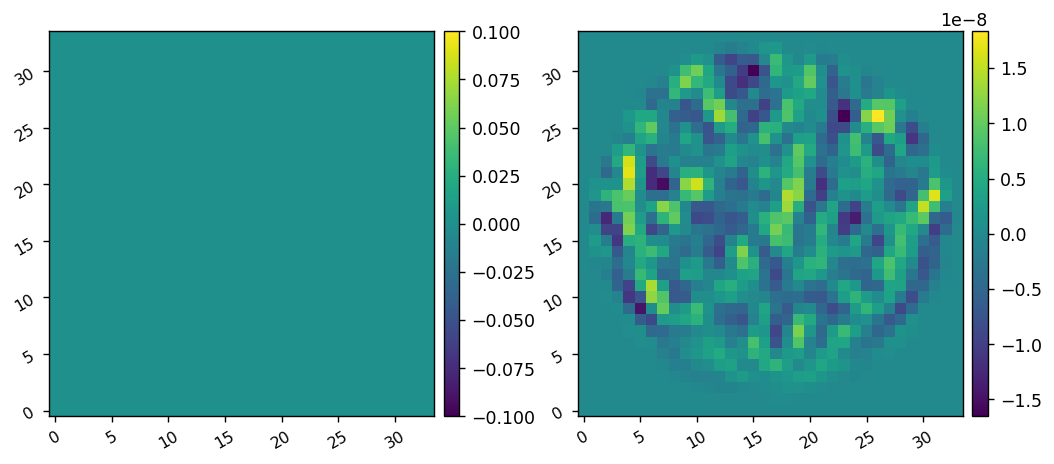

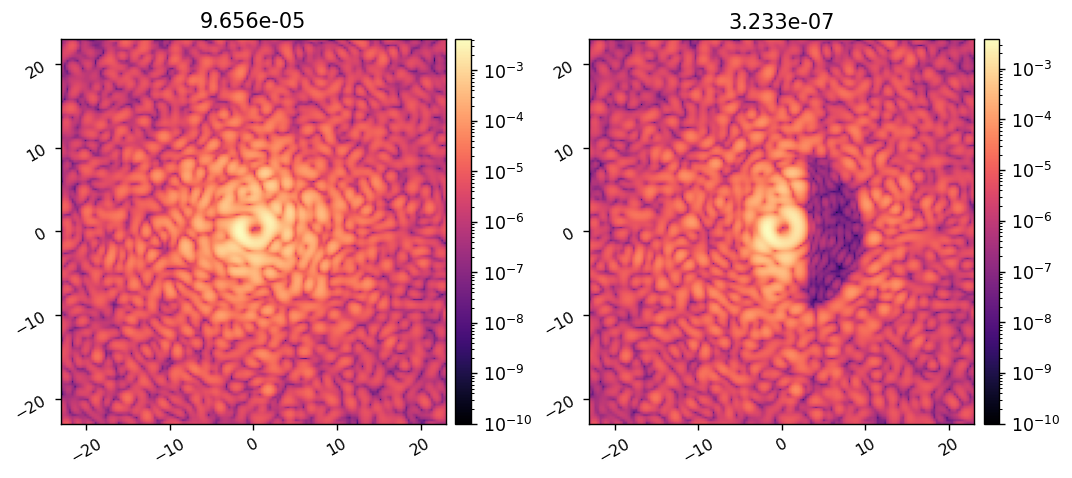

In [7]:
old_command = scoobm.acts_to_command(current_acts, I.dm_mask)
del_command = scoobm.acts_to_command(res.x, I.dm_mask)
print(del_command[25,21])

I.set_dm(old_command)
old_im = I.snap()
I.set_dm(old_command + del_command)
new_im = I.snap()

imshow2(old_command, del_command, cmap1='viridis', cmap2='viridis')
imshow2(old_im, new_im, 
        f'{xp.mean(old_im[control_mask]):.3e}', f'{xp.mean(new_im[control_mask]):.3e}',
        lognorm=True, pxscl=I.psf_pixelscale_lamDc, vmin1=1e-10, vmin2=1e-10)

In [32]:
utils.save_fits('ad_test_acts.fits', I.get_dm()[I.dm_mask])

Saved data to:  ad_test_acts.fits


In [8]:
I.zero_dm()
data = {
    'images':[ref_coro_im],
    'efields':[],
    'commands':[],
    'del_commands':[],
    'reg_conds':[],
    'bfgs_tols':[],
    'pixelscale':I.psf_pixelscale_lamDc,
    'control_mask':control_mask, 
}

Running iteration 7
Computing E-field with model ...
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =          952     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.00000D+00    |proj g|=  6.53905D+07


 This problem is unconstrained.



At iterate    1    f=  9.85490D-01    |proj g|=  4.14524D+07

At iterate    2    f=  9.78012D-01    |proj g|=  3.32326D+07

At iterate    3    f=  9.58865D-01    |proj g|=  4.90626D+07

At iterate    4    f=  9.52876D-01    |proj g|=  1.91358D+07

At iterate    5    f=  9.50673D-01    |proj g|=  1.84357D+07

At iterate    6    f=  9.43206D-01    |proj g|=  2.05412D+07

At iterate    7    f=  9.40471D-01    |proj g|=  6.91265D+07

At iterate    8    f=  9.33273D-01    |proj g|=  2.43347D+07

At iterate    9    f=  9.29354D-01    |proj g|=  1.90923D+07

At iterate   10    f=  9.24896D-01    |proj g|=  1.96050D+07

At iterate   11    f=  9.17165D-01    |proj g|=  2.73235D+07

At iterate   12    f=  9.11720D-01    |proj g|=  3.76790D+07

At iterate   13    f=  9.04730D-01    |proj g|=  2.89727D+07

At iterate   14    f=  8.97770D-01    |proj g|=  3.10339D+07

At iterate   15    f=  8.92778D-01    |proj g|=  4.56717D+07

At iterate   16    f=  8.86441D-01    |proj g|=  2.20579D+07

At iter

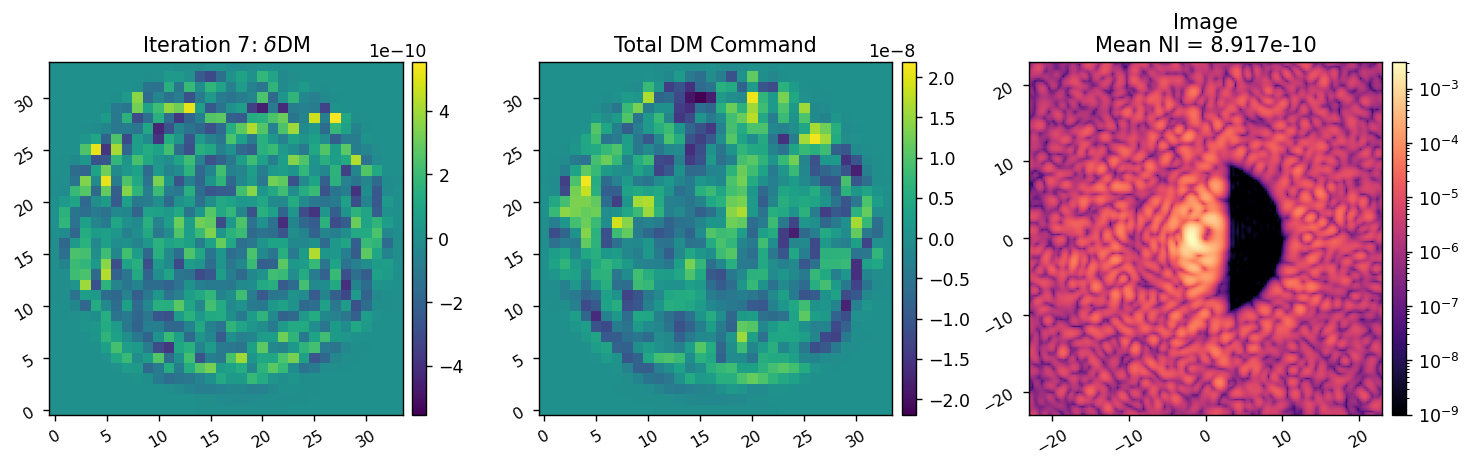

Running iteration 8
Computing E-field with model ...
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =          952     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.00000D+00    |proj g|=  2.09339D+07


 This problem is unconstrained.



At iterate    1    f=  9.99045D-01    |proj g|=  1.55435D+07

At iterate    2    f=  9.96156D-01    |proj g|=  1.28291D+07

At iterate    3    f=  9.94140D-01    |proj g|=  4.00182D+07

At iterate    4    f=  9.91923D-01    |proj g|=  1.70111D+07

At iterate    5    f=  9.90637D-01    |proj g|=  1.79533D+07

At iterate    6    f=  9.87335D-01    |proj g|=  1.60963D+07

At iterate    7    f=  9.86728D-01    |proj g|=  5.16925D+07

At iterate    8    f=  9.84152D-01    |proj g|=  1.92419D+07

At iterate    9    f=  9.82491D-01    |proj g|=  9.66411D+06

At iterate   10    f=  9.81072D-01    |proj g|=  1.71389D+07

At iterate   11    f=  9.78645D-01    |proj g|=  2.00638D+07

At iterate   12    f=  9.75233D-01    |proj g|=  4.82109D+07

At iterate   13    f=  9.69476D-01    |proj g|=  2.12843D+07

At iterate   14    f=  9.65454D-01    |proj g|=  1.58902D+07

At iterate   15    f=  9.60624D-01    |proj g|=  2.47194D+07

At iterate   16    f=  9.58570D-01    |proj g|=  2.54948D+07

At iter

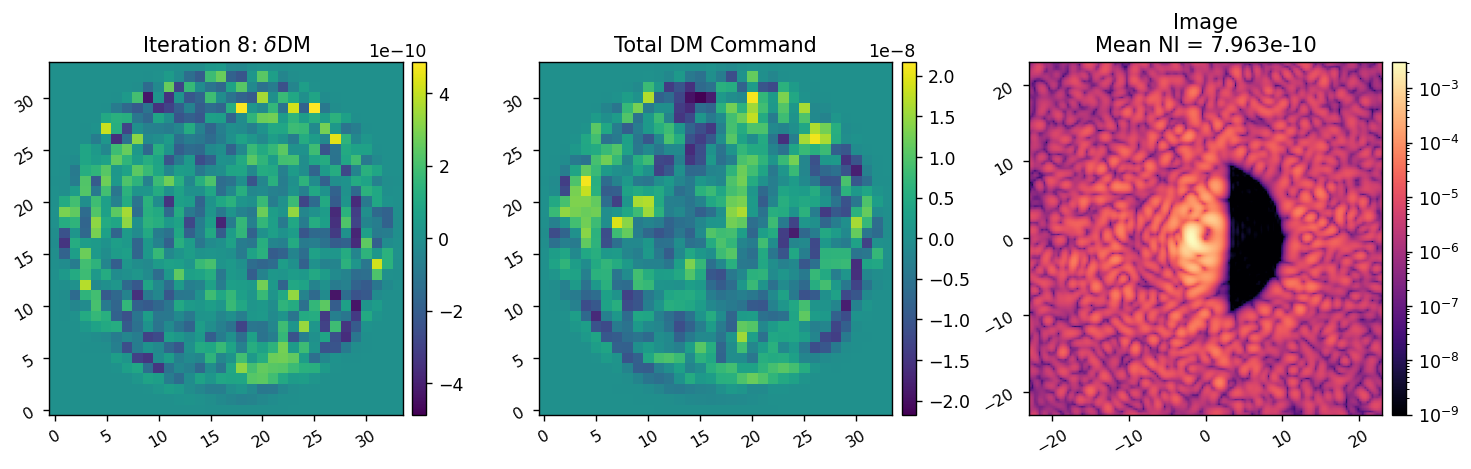

Running iteration 9
Computing E-field with model ...
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =          952     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.00000D+00    |proj g|=  2.52738D+07


 This problem is unconstrained.



At iterate    1    f=  9.98704D-01    |proj g|=  1.75794D+07

At iterate    2    f=  9.94474D-01    |proj g|=  1.60829D+07

At iterate    3    f=  9.92168D-01    |proj g|=  5.32939D+07

At iterate    4    f=  9.88954D-01    |proj g|=  1.57728D+07

At iterate    5    f=  9.87872D-01    |proj g|=  1.51577D+07

At iterate    6    f=  9.83273D-01    |proj g|=  2.43597D+07

At iterate    7    f=  9.81322D-01    |proj g|=  3.04868D+07

At iterate    8    f=  9.78987D-01    |proj g|=  1.94240D+07

At iterate    9    f=  9.75227D-01    |proj g|=  2.22269D+07

At iterate   10    f=  9.71905D-01    |proj g|=  3.92727D+07

At iterate   11    f=  9.67715D-01    |proj g|=  2.72429D+07

At iterate   12    f=  9.61912D-01    |proj g|=  2.39518D+07

At iterate   13    f=  9.59082D-01    |proj g|=  4.66793D+07

At iterate   14    f=  9.55010D-01    |proj g|=  2.69774D+07

At iterate   15    f=  9.51904D-01    |proj g|=  1.84196D+07

At iterate   16    f=  9.49816D-01    |proj g|=  2.19822D+07

At iter

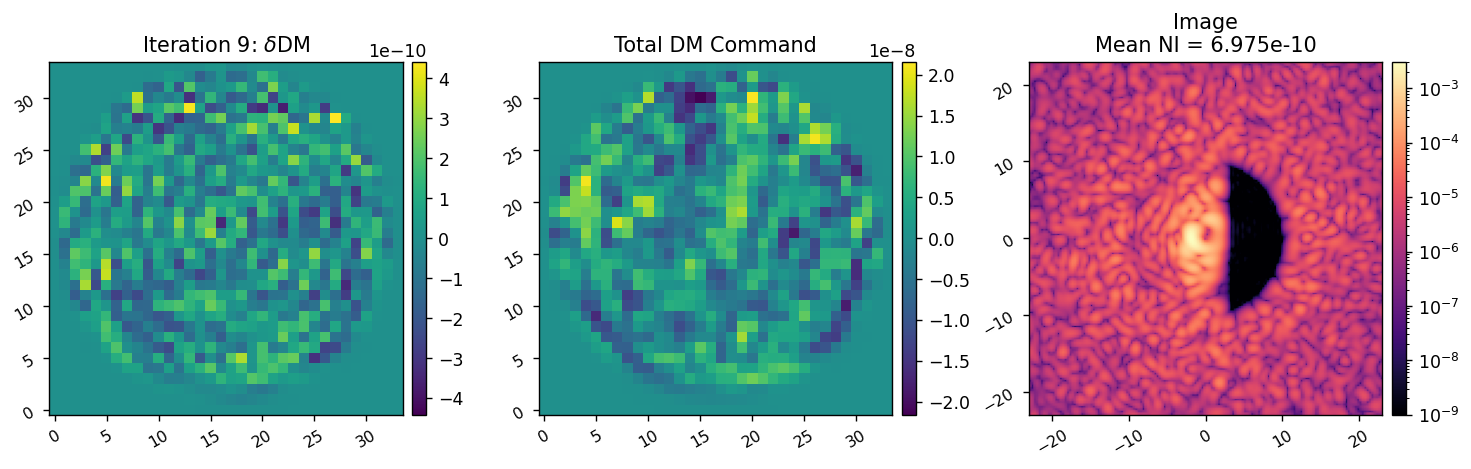

In [11]:
reload(scoobm)
reload(adefc)
reload(utils)

r_cond = 1e-1
r_cond = 1e-2
r_cond = 1e-3
# r_cond = 1e-4
# r_cond = 1e-5
# r_cond = 1e-6
# r_cond = 1e-7
# r_cond = 1e-8
# r_cond = 1e-10

bfgs_tol = 1e-2
bfgs_tol = 1e-3
bfgs_tol = 1e-4
# bfgs_tol = 1e-5

bfgs_opts = {
    'disp':1,
    'maxiter':50,
    'maxls':10,
    # 'ftol':1e-6,
    # 'gtol':1e-6,
}

data = adefc.run(
    I, 
    M, 
    scoobm.val_and_grad, 
    control_mask, 
    data,
    Nitr=3, 
    reg_cond=r_cond,
    bfgs_tol=bfgs_tol,
    bfgs_opts=bfgs_opts,
    gain=1,
)

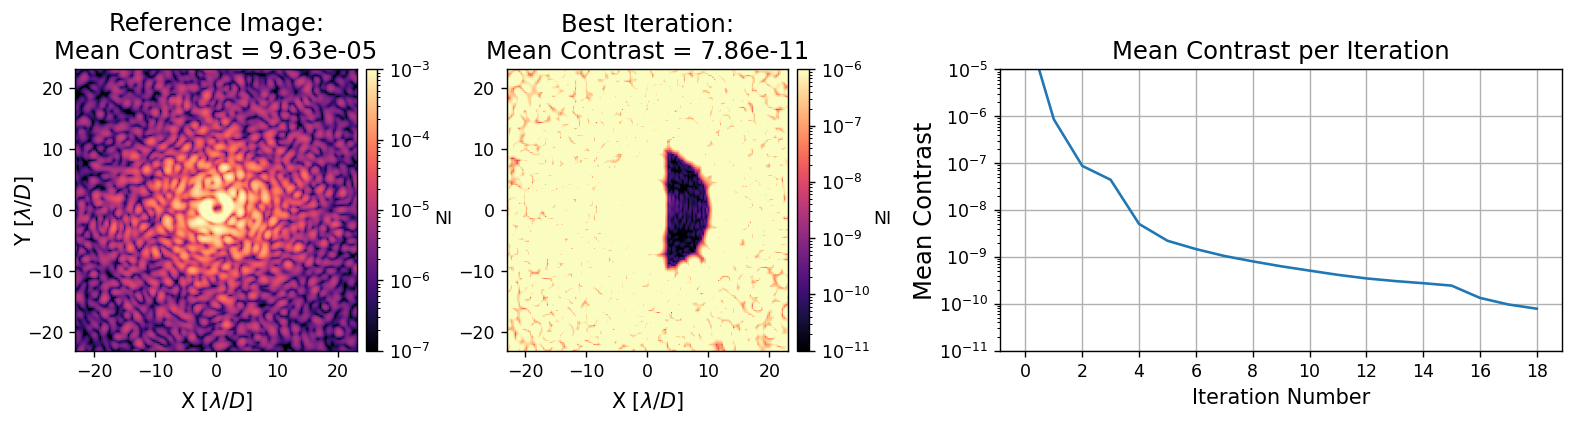

In [34]:
import adefc_vortex.imshows as imshows
reload(imshows)
imshows.plot_data_with_ref(
    data, 
    vmin=1e-11, vmax=1e-5,
    im1vmin=1e-7, im1vmax=1e-3,
    im2vmin=1e-11, im2vmax=1e-6,
)
